In [81]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np


#Getting data ready (turning images into tensors)

In [82]:
import pandas as pd
labels_csv = pd.read_csv("/Users/lukeopany/Desktop/dog-vision/labels.csv")
labels_csv.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


<Axes: xlabel='breed'>

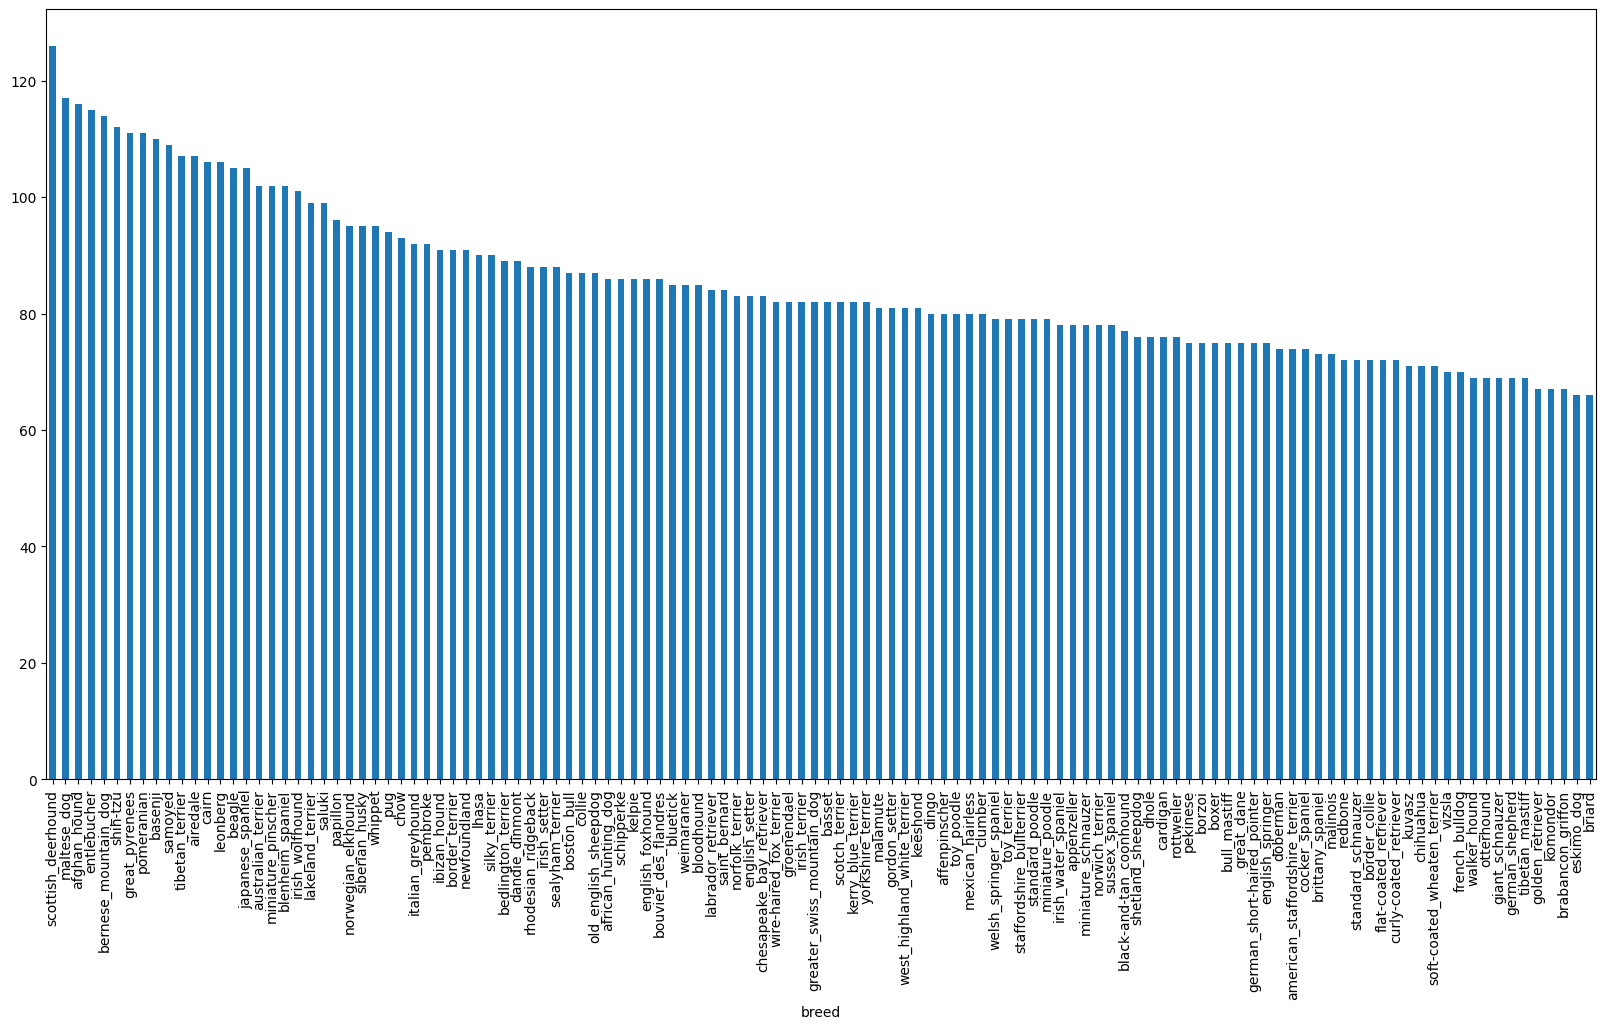

In [83]:
#Find out how many dog breeds are there for each class and plot
labels_csv["breed"].value_counts().plot.bar(figsize=(20,10))

In [84]:
print(labels_csv["breed"].value_counts().mean())

85.18333333333334


In [85]:
#Viewing an image inside the notebook -- copy the image file path and include image id

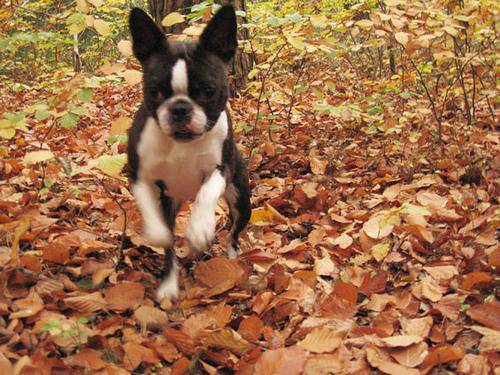

In [86]:
from IPython.display import Image
Image("/Users/lukeopany/Desktop/dog-vision/train/000bec180eb18c7604dcecc8fe0dba07.jpg")

Because it would take a lot of time to type out the filepath each time we need to get an image, we are going to create a pathname from image IDs

In [87]:
#Create pathname from image ID's
filename = "/Users/lukeopany/Desktop/dog-vision/train/" + labels_csv["id"] + ".jpg"
# Avoid printing the full Series (can freeze the notebook output)
filename.head()

0    /Users/lukeopany/Desktop/dog-vision/train/000b...
1    /Users/lukeopany/Desktop/dog-vision/train/0015...
2    /Users/lukeopany/Desktop/dog-vision/train/001c...
3    /Users/lukeopany/Desktop/dog-vision/train/0021...
4    /Users/lukeopany/Desktop/dog-vision/train/0021...
Name: id, dtype: str

In [88]:
#Check whether the number of filenames matches the number of actual images

In [89]:
import os

# Get the list of all files in the training directory
train_path = "/Users/lukeopany/Desktop/dog-vision/train/"
files = os.listdir(train_path)

# Compare the lengths
print(f"Number of filenames generated: {len(filename)}")
print(f"Number of actual images in folder: {len(files)}")

if len(filename) == len(files):
    print("Success: The number of filenames matches the number of actual images.")
else:
    print("Warning: The number of filenames does not match the number of actual images.")

Number of filenames generated: 10222
Number of actual images in folder: 10222
Success: The number of filenames matches the number of actual images.


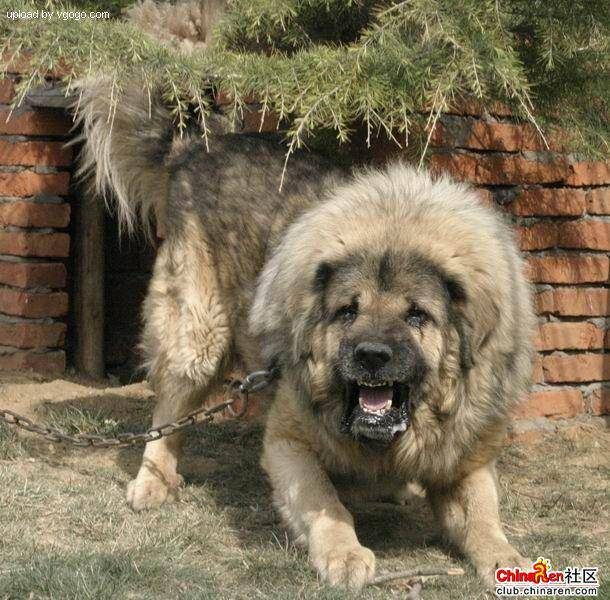

In [90]:
#One more check
from IPython.display import Image
Image(filename[9000])

In [91]:
labels_csv['breed'][9000]

'tibetan_mastiff'

Since we've now got our training image filepath in a list, let's prepare our lables

In [92]:
import numpy as np
labels = labels_csv['breed']
labels = np.array(labels)
len(labels)

10222

In [93]:
#compare the number of labels to the number in files

In [94]:
# Compare the number of labels to the number of actual images in the folder
print(f"Number of labels: {len(labels)}")
print(f"Number of actual images in folder: {len(files)}")

if len(labels) == len(files):
    print("Success: The number of labels matches the number of actual images.")
else:
    print("Warning: There is a mismatch between the number of labels and image files.")

Number of labels: 10222
Number of actual images in folder: 10222
Success: The number of labels matches the number of actual images.


In [95]:
# Find the unique value labels
unique_breeds = np.unique(labels)
len(unique_breeds)

120

In [96]:
# Turn a single label into an array of booleans
labels[0] == unique_breeds

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False])

In [97]:
# Turn every label into an array of booleans
boolean_labels = [label == unique_breeds for label in labels]
boolean_labels[:2]

[array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False]),
 array([False, False, False, False, False, Fal

In [98]:
len(boolean_labels)

10222

In [99]:
# Example: Turning a boolean array into integers
print(labels[0]) # Original labels
print(np.where(unique_breeds == labels[0])) #index where label occurs
print(boolean_labels[0].argmax()) # index where label occurs in boolean array
print(boolean_labels[0].astype(int)) # There will be a 1 where the sample occurs



boston_bull
(array([19]),)
19
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [100]:
print(labels[2])
print(boolean_labels[2].astype(int))


pekinese
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0]


In [101]:
filename[:10]

0    /Users/lukeopany/Desktop/dog-vision/train/000b...
1    /Users/lukeopany/Desktop/dog-vision/train/0015...
2    /Users/lukeopany/Desktop/dog-vision/train/001c...
3    /Users/lukeopany/Desktop/dog-vision/train/0021...
4    /Users/lukeopany/Desktop/dog-vision/train/0021...
5    /Users/lukeopany/Desktop/dog-vision/train/0022...
6    /Users/lukeopany/Desktop/dog-vision/train/0029...
7    /Users/lukeopany/Desktop/dog-vision/train/002a...
8    /Users/lukeopany/Desktop/dog-vision/train/003d...
9    /Users/lukeopany/Desktop/dog-vision/train/0042...
Name: id, dtype: str

This whole process has been trying to get our data into an accesible format

Creating our own validation set

In [102]:
#This can be achieved by creating the X and y variable (normally for test-train split but can be used in our case to split the data into train - val)

In [103]:
x = filename
y = boolean_labels

In [104]:
len(x), len(y)

(10222, 10222)

In [105]:
#To save time, start with ~1000 samples 

In [106]:
# Set the number of images to use for experimenting
NUM_IMAGES = 1000
# Split into train and validation sets (80/20 split)
NUM_TRAIN = int(NUM_IMAGES * 0.8)  # 800 images for training -- int ensures no float(decimals)

x_train = x[:NUM_TRAIN]
y_train = y[:NUM_TRAIN]

x_val = x[NUM_TRAIN:NUM_IMAGES]
y_val = y[NUM_TRAIN:NUM_IMAGES]

print(f"Training samples:   {len(x_train)}")
print(f"Validation samples: {len(x_val)}")

Training samples:   800
Validation samples: 200


In [107]:
x_train[:5], y_train[:2]

(0    /Users/lukeopany/Desktop/dog-vision/train/000b...
 1    /Users/lukeopany/Desktop/dog-vision/train/0015...
 2    /Users/lukeopany/Desktop/dog-vision/train/001c...
 3    /Users/lukeopany/Desktop/dog-vision/train/0021...
 4    /Users/lukeopany/Desktop/dog-vision/train/0021...
 Name: id, dtype: str,
 [array([False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False,  True, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False

Since our labels are already numerical, let's turn our images(filepaths) into tensors

Tensors are a numerical representation -- kind of like a matrix

Write a function to turn a file path into a tensor
 1. Take an image file path as input
 2. Use TensorFlow to read the image from the file and save it to a variable 'image'
 3. Turn our 'image' into a tensors
 4. Normalize our image: Convert color channels from 0-255 to 0-1
 5. Resize the image to a target size (e.g., 224x224 pixels)
 6. Return the modified 'image'

In [108]:
from matplotlib.pyplot import imread
image = imread(x_train[0])
image.max(), image.min(), image.shape, image[:2]

(255,
 0,
 (375, 500, 3),
 array([[[108,  46,   0],
         [152,  92,  42],
         [180, 120,  70],
         ...,
         [176, 144,  69],
         [189, 157,  82],
         [214, 182, 107]],
 
        [[151,  93,  47],
         [179, 121,  75],
         [167, 111,  64],
         ...,
         [167, 136,  56],
         [172, 139,  60],
         [188, 157,  77]]], dtype=uint8))

In [109]:
#Turn image into a tensor (this is what an image looks like as a tensor)
tf.constant(image)[:2]

<tf.Tensor: shape=(2, 500, 3), dtype=uint8, numpy=
array([[[108,  46,   0],
        [152,  92,  42],
        [180, 120,  70],
        ...,
        [176, 144,  69],
        [189, 157,  82],
        [214, 182, 107]],

       [[151,  93,  47],
        [179, 121,  75],
        [167, 111,  64],
        ...,
        [167, 136,  56],
        [172, 139,  60],
        [188, 157,  77]]], dtype=uint8)>

In [110]:
#Define image size(ensures images are the same size)
IMAGE_SIZE = (224, 224)

#Create a function for preprocessing an images
def preprocess_image(file_path):
    # Read the image from the file
    image = tf.io.read_file(file_path)
    # Decode the image into a tensor
    image = tf.image.decode_jpeg(image, channels=3)
    # Normalize pixel values from [0, 255] to [0, 1]
    image = tf.image.convert_image_dtype(image, tf.float32)
    # Resize the image to the target size
    image = tf.image.resize(image, IMAGE_SIZE)
    return image

In [111]:
#Turning our data into batches so they process efficiently
#create a simple function to return a tuple of tensors (preprocessed image, label)
def get_image_label(image_path, label):
    image = preprocess_image(image_path)
    return image, label

In [112]:
#Demo of the functiona above
get_image_label(x_train[0], tf.constant(y_train[0]))

(<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
 array([[[0.5705322 , 0.33588538, 0.15008472],
         [0.66901225, 0.46011657, 0.26022965],
         [0.6106236 , 0.43763575, 0.21601692],
         ...,
         [0.8182316 , 0.7297959 , 0.2696411 ],
         [0.7245514 , 0.60591483, 0.26530695],
         [0.74945515, 0.62528676, 0.32456023]],
 
        [[0.6761415 , 0.47337607, 0.30642927],
         [0.5672121 , 0.38192675, 0.2034954 ],
         [0.58835465, 0.432257  , 0.24031542],
         ...,
         [0.93269396, 0.8260498 , 0.41093385],
         [0.86073047, 0.74251217, 0.3694168 ],
         [0.767815  , 0.6461587 , 0.2929112 ]],
 
        [[0.46350825, 0.29595745, 0.15361558],
         [0.42554113, 0.27039403, 0.12009469],
         [0.7887873 , 0.65473604, 0.4901498 ],
         ...,
         [0.8937206 , 0.7696364 , 0.41811714],
         [0.8860994 , 0.75859594, 0.36496204],
         [0.82435924, 0.6949474 , 0.2930566 ]],
 
        ...,
 
        [[0.7344025 , 0.4716574 

In [113]:
BATCH_SIZE = 32

def create_data_batches(x, y=None, batch_size=BATCH_SIZE, valid_data=False, test_data=False):
    if test_data:
        data = tf.data.Dataset.from_tensor_slices(tf.constant(x))
        data = data.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
        data = data.batch(batch_size)
        data = data.prefetch(tf.data.AUTOTUNE)
        return data

    y = np.array(y).astype(np.float32)

    data = tf.data.Dataset.from_tensor_slices((tf.constant(x), tf.constant(y)))

    if not valid_data:
        data = data.shuffle(buffer_size=len(x))

    data = data.map(get_image_label, num_parallel_calls=tf.data.AUTOTUNE)
    data = data.batch(batch_size)
    data = data.prefetch(tf.data.AUTOTUNE)

    return data

In [114]:
train_data = create_data_batches(x_train, y_train)
val_data = create_data_batches(x_val, y_val, valid_data=True)

print(train_data.element_spec)

(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 120), dtype=tf.float32, name=None))


In [115]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define the function for viewing images
def show_25_images(images, labels, unique_breeds):
    """
    Displays a plot of 25 images and their labels from a data batch.
    """
    # Setup the figure size (10 inches by 10 inches)
    plt.figure(figsize=(10, 10))
    
    # Loop through 25 (for displaying 25 images)
    for i in range(25):
        # Create subplots (5 rows, 5 columns)
        # The i+1 is because matplotlib subplots are 1-indexed
        ax = plt.subplot(5, 5, i + 1)
        
        # Display an image
        plt.imshow(images[i])
        
        # Add the image label as the title
        # labels[i].argmax() finds the index of the highest value (the "1" in one-hot encoding)
        plt.title(unique_breeds[labels[i].argmax()])
        
        # Turn the grid lines and axes off for a clean look
        plt.axis("off")




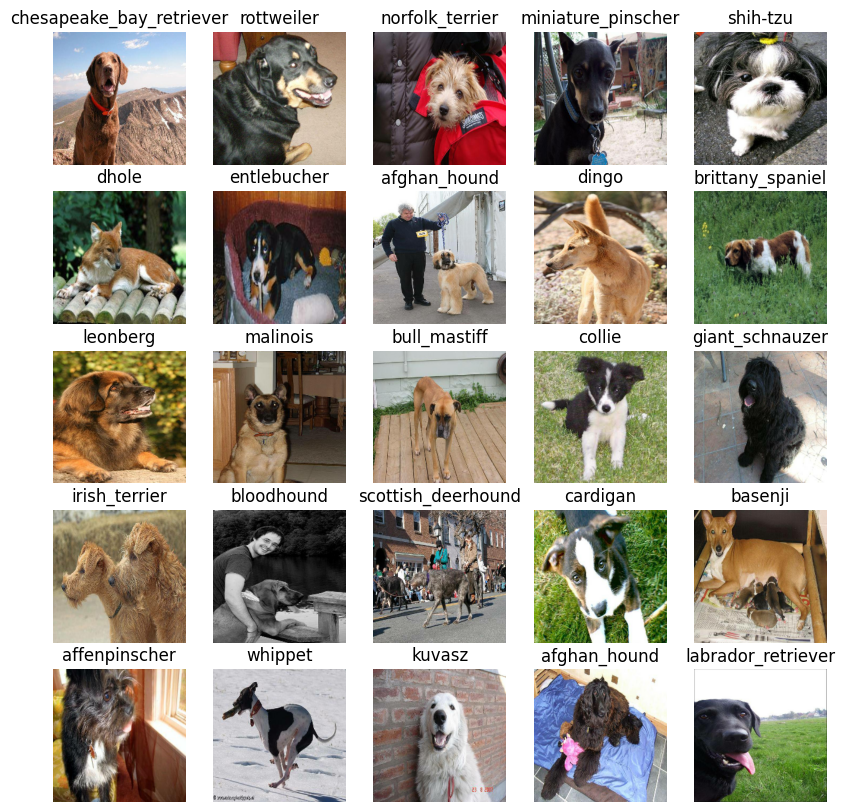

In [117]:
show_25_images(*train_data.as_numpy_iterator().next(), unique_breeds=unique_breeds)

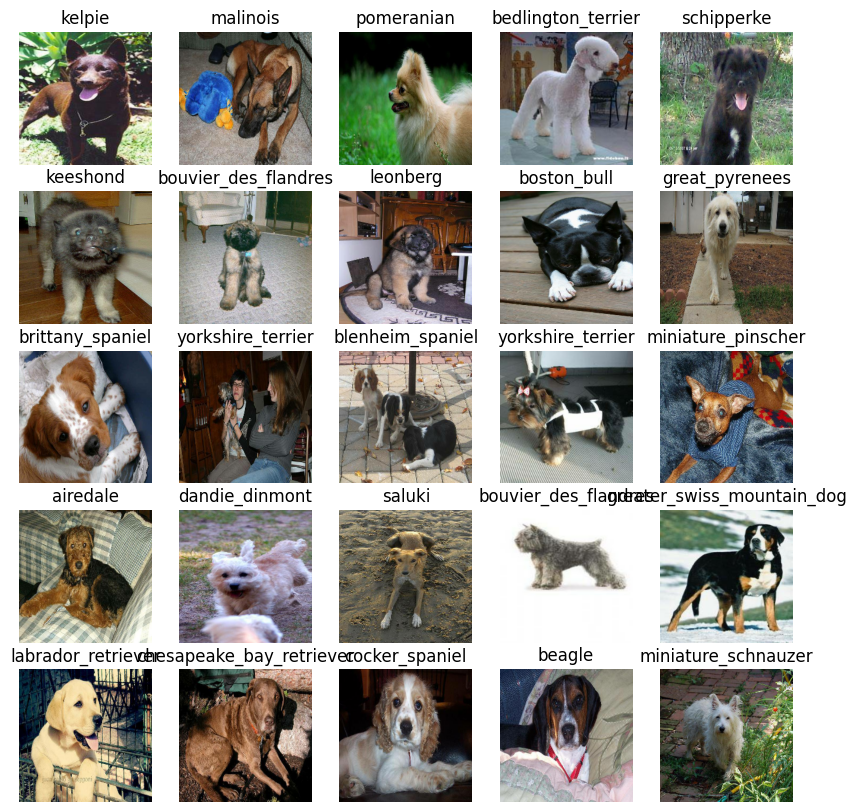

In [ ]:

show_25_images(*val_data.as_numpy_iterator().next(), unique_breeds=unique_breeds)